In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data.csv", encoding='cp1252')
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [3]:
df.shape

(435742, 13)

In [4]:
df.columns.tolist()

['stn_code',
 'sampling_date',
 'state',
 'location',
 'agency',
 'type',
 'so2',
 'no2',
 'rspm',
 'spm',
 'location_monitoring_station',
 'pm2_5',
 'date']

In [8]:
city_std = df.groupby("location")["pm2_5"].std().dropna()
city_std = city_std.sort_values(ascending=False)
city_std.head(10)

location
Bhopal         64.467586
Delhi          47.127178
Kolkata        37.418249
Bhubaneswar    37.134667
Puri           33.410183
Howrah         32.623109
Talcher        32.575951
Mapusa         27.860099
Sangareddy     27.228373
Keonjhar       25.408311
Name: pm2_5, dtype: float64

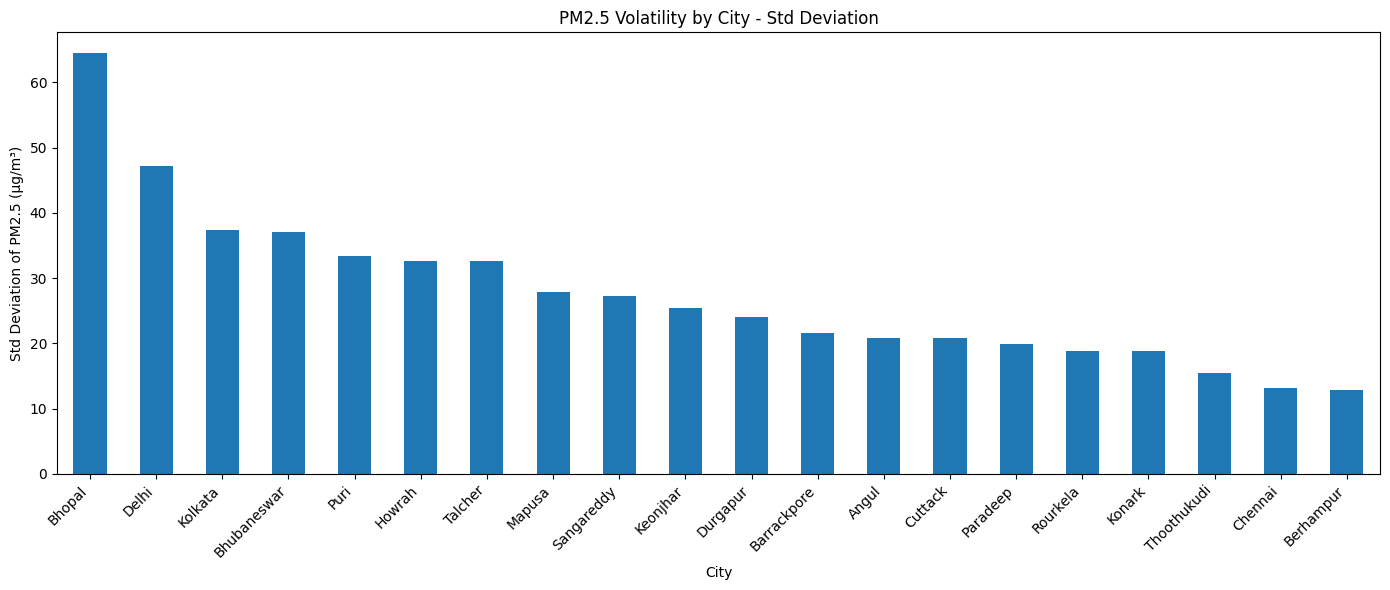

In [9]:
plt.figure(figsize=(14, 6))
city_std.head(20).plot(kind="bar")
plt.title("PM2.5 Volatility by City - Std Deviation")
plt.xlabel("City")
plt.ylabel("Std Deviation of PM2.5 (µg/m³)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("city_pm25_std_dev.png", dpi=150)
plt.show()

In [10]:
bhopal = df[df["location"] == "Bhopal"]["pm2_5"].dropna().values
print(f"Bhopal readings : {len(bhopal)}")
print(f"Bhopal mean     : {np.mean(bhopal):.2f}")
print(f"Bhopal max      : {np.max(bhopal):.2f}")
print(f"Bhopal min      : {np.min(bhopal):.2f}")

Bhopal readings : 390
Bhopal mean     : 79.10
Bhopal max      : 395.00
Bhopal min      : 4.00
